# 🧠 Data Preprocessing and Model Over/Underfitting

In this notebook, you will learn
- How to prepare data for Machine Learning models
- Why scaling, encoding, and imputation matter
- What Overfitting and Underfitting means for a model

In [50]:
# essential imports
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

## Load and Explore Dataset
For this part of today's session, we will use the "Heart Failure" dataset.

In [ ]:
# load dataset
url = "https://github.com/RogueRefiner/TU_UA/Lecture_5/heart.cvs"
heart_data_raw = pd.read_csv(url). 
heart_data_raw.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [25]:
print(heart_data_raw.shape)

(918, 12)


In [26]:
heart_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [27]:
X_heart_raw = heart_data_raw.loc[:, heart_data_raw.columns != "HeartDisease"]
y_heart_raw = pd.Series(heart_data_raw["HeartDisease"])

In [54]:
# for later usage
numeric_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

### Exercise 1
1. What are the **features** and what is the **target** in the dataset?
2. Check the **distribution of the target values** - are the classes balanced? (*Hint: y_heart_raw.value_counts()*)

In [28]:
... # Your Code here

Ellipsis

## Handling Missing Values

In the real world, data often has so called missing values (`NaN`). Before being able to train any machine learning models, we have to find a way to deal with the missing data.

In [56]:
# count the number of missing values
X_heart_raw.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
dtype: int64

We can see that this dataset has no missing values, which might not be very realistic. For now, we will simulate having missing values to learn how to deal with them.

In [35]:
# Simulate missing data
X_heart_missing = X_heart_raw.copy()
mask = np.random.rand(*X_heart_missing.shape) < 0.1     # ~ 10% missing values

X_heart_missing[mask] = np.nan
X_heart_missing.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,NaN,M,ATA,140.0,289.0,0.0,Normal,172.0,N,0.0,Up
1,49.0,F,NaN,NaN,180.0,0.0,Normal,156.0,NaN,1.0,Flat
2,37.0,M,ATA,NaN,283.0,0.0,ST,98.0,N,0.0,Up
3,48.0,F,ASY,138.0,214.0,NaN,Normal,108.0,Y,1.5,Flat
4,54.0,M,NAP,150.0,195.0,0.0,Normal,122.0,N,0.0,NaN


*Sklearn* provides several strategies for **data imputation**, which means replacing the missing values with meaningful ones. (*Of course there are more but for now the following three are enough :)*)
- **Mean Imputation**
- **Median Imputation**
- **Most frequent Imputation**

Which one to use?

In [38]:
mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')
most_frequent_imputer = SimpleImputer(strategy='most_frequent')

In [57]:
X_heart_filled_numeric = pd.DataFrame(mean_imputer.fit_transform(X_heart_missing.loc[:, X_heart_missing.columns.isin(numeric_features)]), 
                                        columns=numeric_features)
X_heart_filled_numeric.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
0,53.673966,140.00000,289.0,172.0,0.0
1,49.000000,132.56432,180.0,156.0,1.0
2,37.000000,132.56432,283.0,98.0,0.0
3,48.000000,138.00000,214.0,108.0,1.5
4,54.000000,150.00000,195.0,122.0,0.0


We can of course also use the median strategy for the numeric data. But what about the categorical data?

### Exercise 2
Perform data imputation on the categorical features.

In [ ]:
... # Your code here

## Encoding Categorical Data
Most of the machine learning models need numeric inputs. Using different **encoding strategies** (e.g. **OneHotEncoder**), we can convert categorical data into numeric data.

In [83]:
one_hot_encoder = OneHotEncoder()
encoded_array = encoder.fit_transform(X_heart_raw[categorical_features]).toarray()
encoded_cols = encoder.get_feature_names_out(encoder.feature_names_in_)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=X_heart_raw.index)
encoded_df.head()

,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [84]:
# combine numeric data with categorical one
heart_data_encoded = pd.concat([heart_data_raw[numeric_features], encoded_df], axis=1)
heart_data_encoded.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,172,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,160,180,156,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,130,283,98,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48,138,214,108,1.5,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,150,195,122,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## Feature Scaling
Some models (e.g. **Perceptron** and **KNN**) are sensitive to the **scale** of our features. Thus, we want to ensure that all features contribute equally. Again, *Sklearn* provides different methods for scaling data. Two commonly used methods are:
- **StandardScaler:** substract mean, divide by std (mean=0, std=1)
- **MinMaxScaler:** scale values to range[0, 1]

In [93]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

X_heart_numeric = heart_data_encoded[numeric_features]

X_standard_scaled = standard_scaler.fit_transform(X_heart_numeric)
X_min_max_scaled = min_max_scaler.fit_transform(X_heart_numeric)

print("----------------------------------")
print("Before scaling:")
print(X_heart_numeric.describe())

print("\nAfter StandardScaler (mean≈0, std≈1):")
print(pd.DataFrame(X_standard_scaled, columns=X_heart_numeric.columns).describe())

print("----------------------------------")
print("Before scaling:")
print(X_heart_numeric.describe())

print("\nAfter MinMaxScaler:")
print(pd.DataFrame(X_min_max_scaled, columns=X_heart_numeric.columns).describe())
print("----------------------------------")

----------------------------------
Before scaling:
              Age   RestingBP  Cholesterol       MaxHR     Oldpeak
count  918.000000  918.000000   918.000000  918.000000  918.000000
mean    53.510893  132.396514   198.799564  136.809368    0.887364
std      9.432617   18.514154   109.384145   25.460334    1.066570
min     28.000000    0.000000     0.000000   60.000000   -2.600000
25%     47.000000  120.000000   173.250000  120.000000    0.000000
50%     54.000000  130.000000   223.000000  138.000000    0.600000
75%     60.000000  140.000000   267.000000  156.000000    1.500000
max     77.000000  200.000000   603.000000  202.000000    6.200000

After StandardScaler (mean≈0, std≈1):
                Age     RestingBP  Cholesterol         MaxHR       Oldpeak
count  9.180000e+02  9.180000e+02   918.000000  9.180000e+02  9.180000e+02
mean  -1.083616e-16  1.954380e-16     0.000000  4.953675e-16  1.238419e-16
std    1.000545e+00  1.000545e+00     1.000545  1.000545e+00  1.000545e+00
min   -

## Over- and Underfitting


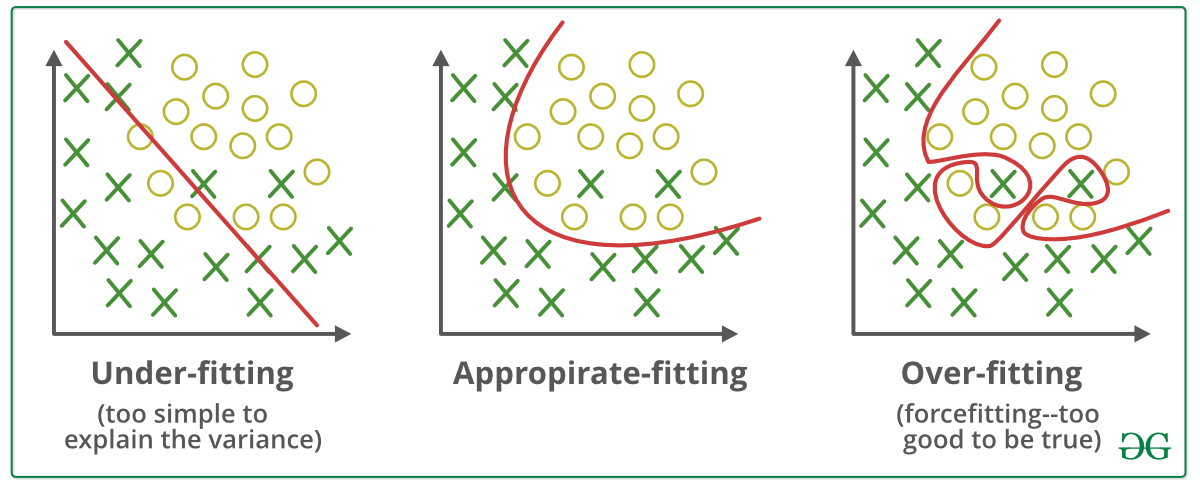